A healthcare organization wants to analyze online patient feedback, medical articles, and web traffic to improve services and provide better patient care.

To achieve this, the organization aims to:

Extract health-related web content from medical websites and forums.
Analyze web responses to understand patient concerns and healthcare trends.
Study web traffic patterns to identify peak usage and service demand.

In [39]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

#### 1. WEB CONTENT MINING

In [40]:
# Extract health related articles/news 

url = "https://www.who.int/news-room"

In [41]:
headers = {"User-Agent": "Mozilla/5.0"}

In [42]:
response = requests.get(url, headers=headers)

In [43]:
soup = BeautifulSoup(response.text, "html.parser")

In [44]:
items = soup.find_all("a")

health_articles = []
links = []

In [45]:
for item in items:
    text = item.get_text(strip=True)
    href = item.get("href")

    if text:
        links.append(text)

    if "2026" in text or "2025" in text:
        health_articles.append(text)

In [46]:
for article in health_articles[:10]:
    print(article)

5 June 2026Joint News ReleaseAfrica CDC and WHO launch joint continental Ebola response plan
4 June 2026Departmental updateCountries unite at WHA79 to advance refugee and migrant health through stronger national systems
4 June 2026Departmental updateEmpowering health-care workers to save lives after toxic chemical exposures: WHO interim clinical guidance
4 June 2026News releaseUnsafe food causes 866 million illnesses and 1.5 million deaths annually, young children at highest risk
Stronger together: milestones that mattered in 2025
29 May 2026Strengthening enforcement of e-cigarette regulations in Rio de Janeiro
5 June 2026WHO Director-General's opening remarks at the launch of the joint Bundibugyo Ebola virus continental strategic preparedness and response plan – 5 June 2026
25 November 2025Invisible frontlines: tackling antimicrobial resistance amid conflict and fragility
2026 - Ebola outbreak - DRCWHO Health Emergencies EPI-WIN webinar: Ebola Bundibugyo virus disease: what we know9 J

#### 2. WEB STRUCTURE MINING

In [47]:
# Analyze link connections in healthcare site
df = pd.DataFrame(links, columns=["Page"])

In [48]:
df

,Page
0,Skip to main content
1,Global
2,Regions
3,Africa
4,Americas
...,...
225,Contact us
226,Newsletters
227,Report misconduct
228,Privacy policy


In [49]:
G = nx.Graph()

In [50]:
for item in items[:20]:
    href = item.get("href")
    if href:
        G.add_edge(url, href)

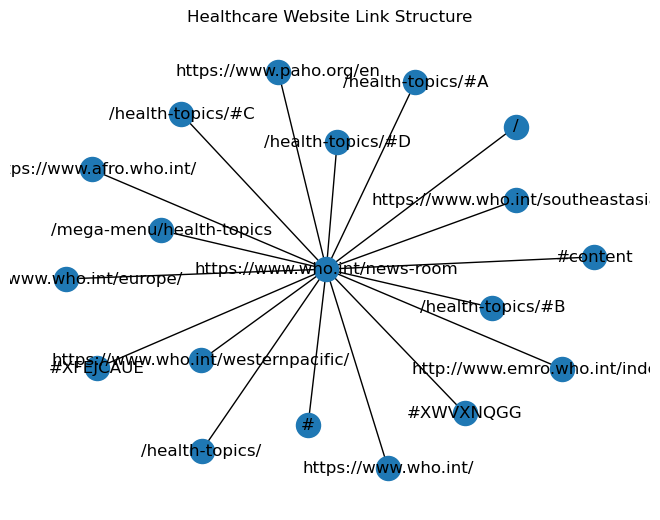

In [51]:
plt.figure()
nx.draw(G, with_labels=True,)
plt.title("Healthcare Website Link Structure")
plt.show()

####  3. WEB USAGE MINING

In [52]:
page_counts = df["Page"].value_counts().head(10)
print(page_counts)

Page
All →                    7
Africa                   3
South-East Asia          3
Regions                  3
Europe                   3
Eastern Mediterranean    3
Western Pacific          3
Americas                 3
D                        2
A                        2
Name: count, dtype: int64


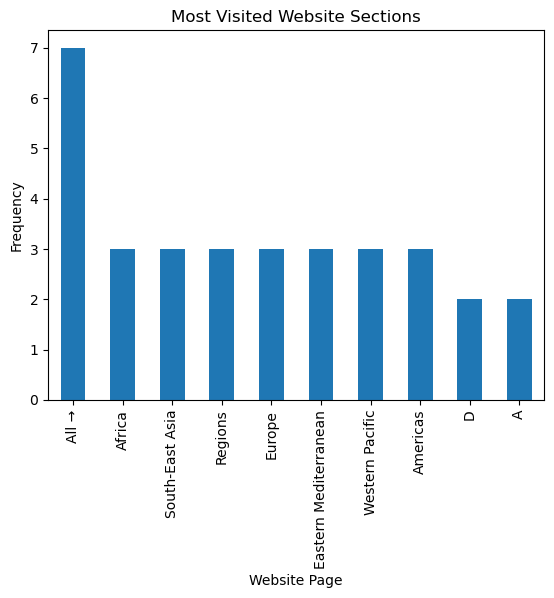

In [56]:
plt.figure()
page_counts.plot(kind="bar")
plt.title("Most Visited Website Sections")
plt.xlabel("Website Page")
plt.ylabel("Frequency")
plt.show()